# Fig 4 — CLT and the scale-estimation effect on amplitude distributions

This figure illustrates the two mechanisms that suppress non-Gaussianity — central-limit averaging by the broad PTA response, and the loss of information under scale normalization — for $N_p=300$ pulsars and $N_s\in\{1,2,10\}$ sources. It plots histograms of the **stacked real and imaginary parts** of $w_I$ (so $2N_p$ real samples per realization) across pulsars, for three source amplitude distributions (uniform, exponential, log-normal), under four response geometries:
1. true PTA antenna pattern, raw (no scale normalization),
2. true PTA antenna pattern, after scale normalization,
3. $30^\circ$ patch response, after scale normalization,
4. $15^\circ$ patch response, after scale normalization.

Before any normalization the linear data is already approximately Gaussian-shaped; the *scale* is the only thing that depends on the underlying amplitude distribution. After dividing by the per-realization empirical standard deviation, the histograms collapse onto $\mathcal{N}(0, 1)$ for the broad PTA response — the source amplitude distribution is washed out. For the narrower patches the CLT fails and the collapse no longer happens, exposing the amplitude statistics.

## How to use this notebook
If you have downloaded this notebook from the repo set `REGENERATE_DATA = True` to recompute the data. It will be saved as `data/fig4_clt_and_scale.npz`.

If you want to save the plot (it is saved under `plots/fig4_clt_and_scale.pdf`), set `SAVE_PLOT` to True.

In [5]:
REGENERATE_DATA = False
SAVE_PLOT = True

In [ ]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats

from helpers.pta_helpers import (
    set_paper_rcparams,
    setup_pta,
    build_patch_response_matrices,
    pick_source_pixels_real,
    pick_source_pixels_patch,
    default_amp_dists,
    generate_samples_multisrc_linear,
)

DATA_PATH = Path('data') / 'fig4_clt_and_scale.npz'
PLOT_PATH = Path('plots') / 'fig4_clt_and_scale.pdf'
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

In [ ]:
NP = 300
NSIDE = 16
N_REAL = 1
NS_LIST = [1, 2, 10]
F_HZ = 1.0 / (16.03 * 365.25 * 86400.0)
PATCH_WIDE_DEG = 30.0
PATCH_NARROW_DEG = 15.0
MIN_SEP_REAL_DEG = 30
MIN_SEP_PATCH_DEG = 20

## Compute or load the samples

`all_data[Ns]` is a dict with four keys (`raw`, `norm`, `patchwide`, `patchnarrow`), each a list of sorted-sample arrays for the three amplitude distributions.

In [7]:
def compute_all_data():
    amp_dists = default_amp_dists()
    fcenter = np.array([F_HZ])
    pta = setup_pta(npulsars=NP, nside=NSIDE, fcenter=fcenter)
    Rp0 = pta['r_p']
    Rc0 = pta['r_c']
    p_vec = pta['p_vec']
    W_real = pta['w_mat_R']

    max_ns = max(NS_LIST)
    source_pixels_real = pick_source_pixels_real(
        Rp0, Rc0, max_ns, NSIDE, min_sep_deg=MIN_SEP_REAL_DEG)
    resp_vectors_real = [
        W_real @ (Rp0[:, pix] + 1j * Rc0[:, pix])
        for pix in source_pixels_real
    ]

    source_pixels_patch = pick_source_pixels_patch(
        p_vec, max_ns, NSIDE, min_sep_deg=MIN_SEP_PATCH_DEG)

    patch_wide = np.deg2rad(PATCH_WIDE_DEG)
    patch_narrow = np.deg2rad(PATCH_NARROW_DEG)

    Rp_pw, Rc_pw, W_pw = build_patch_response_matrices(
        p_vec, patch_wide, NSIDE, np.random.default_rng(123))
    resp_vectors_patch_wide = [
        W_pw @ (Rp_pw[:, pix] + 1j * Rc_pw[:, pix])
        for pix in source_pixels_patch
    ]

    Rp_pn, Rc_pn, W_pn = build_patch_response_matrices(
        p_vec, patch_narrow, NSIDE, np.random.default_rng(456))
    resp_vectors_patch_narrow = [
        W_pn @ (Rp_pn[:, pix] + 1j * Rc_pn[:, pix])
        for pix in source_pixels_patch
    ]

    all_data = {}
    for ns in NS_LIST:
        print(f'  Ns = {ns}')
        resp_real_sub = resp_vectors_real[:ns]
        raw_real, norm_real = generate_samples_multisrc_linear(
            resp_real_sub, amp_dists, N_REAL, 100 * ns)
        resp_pw_sub = resp_vectors_patch_wide[:ns]
        _, norm_pw = generate_samples_multisrc_linear(
            resp_pw_sub, amp_dists, N_REAL, 200 * ns)
        resp_pn_sub = resp_vectors_patch_narrow[:ns]
        _, norm_pn = generate_samples_multisrc_linear(
            resp_pn_sub, amp_dists, N_REAL, 300 * ns)
        all_data[ns] = {
            'raw':         [raw_real[name]  for name, _ in amp_dists],
            'norm':        [norm_real[name] for name, _ in amp_dists],
            'patchwide':   [norm_pw[name]   for name, _ in amp_dists],
            'patchnarrow': [norm_pn[name]   for name, _ in amp_dists],
        }
    return all_data, amp_dists

In [8]:
if REGENERATE_DATA or not DATA_PATH.exists():
    print('Computing samples ...')
    all_data, amp_dists = compute_all_data()
    # Flatten dict-of-dict-of-lists into named arrays for npz.
    flat = {'ns_list': np.array(NS_LIST, dtype=int),
            'amp_names': np.array([n for n, _ in amp_dists])}
    for ns in NS_LIST:
        for key in ('raw', 'norm', 'patchwide', 'patchnarrow'):
            for i, (name, _) in enumerate(amp_dists):
                flat[f'Ns{ns}_{key}_{name}'] = all_data[ns][key][i]
    np.savez(DATA_PATH, **flat)
    print(f'Saved {DATA_PATH}')
else:
    data = np.load(DATA_PATH)
    ns_list = list(np.asarray(data['ns_list']).astype(int))
    amp_names = list(np.asarray(data['amp_names']).astype(str))
    amp_dists = [(n, None) for n in amp_names]  # only names needed for plot
    all_data = {}
    for ns in ns_list:
        all_data[ns] = {}
        for key in ('raw', 'norm', 'patchwide', 'patchnarrow'):
            all_data[ns][key] = [data[f'Ns{ns}_{key}_{name}'] for name in amp_names]
    NS_LIST = ns_list
    print(f'Loaded {DATA_PATH} (Ns = {NS_LIST})')

Loaded data/fig4_clt_and_scale.npz (Ns = [np.int64(1), np.int64(2), np.int64(10)])


## Plot the histograms

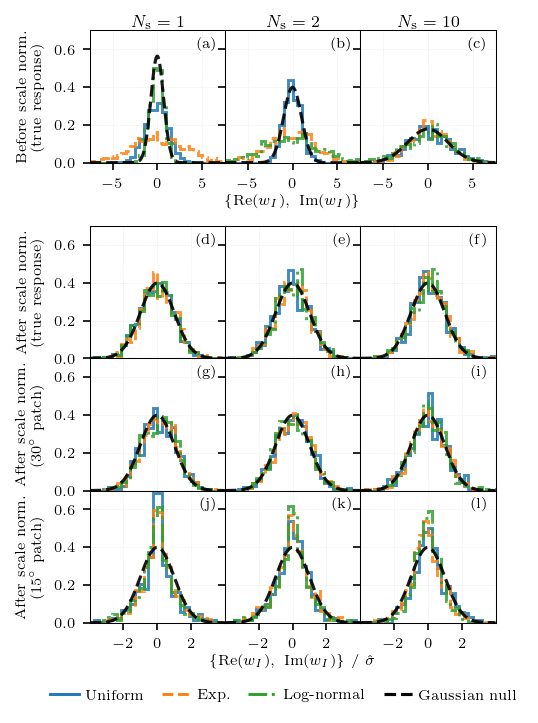

Saved plots/fig4_clt_and_scale.pdf


In [10]:
use_tex, COLUMN_W, _ = set_paper_rcparams()

amp_dists_plot = [
    ('uniform', 'Uniform',     'C0'),
    ('exp',     'Exp.',        'C1'),
    ('lognorm', 'Log-normal',  'C2'),
]
linestyles = ['-', '--', '-.']

raw_max = float(np.percentile(np.abs(
    np.concatenate([all_data[ns]['raw'][i] for ns in NS_LIST for i in range(3)])
), 99.5))
xlim_raw  = (-raw_max, raw_max)
xlim_norm = (-4.0, 4.0)
x_th_raw  = np.linspace(xlim_raw[0],  xlim_raw[1],  500)
x_th_norm = np.linspace(xlim_norm[0], xlim_norm[1], 500)
raw_bins  = np.linspace(xlim_raw[0],  xlim_raw[1],  31)
norm_bins = np.linspace(xlim_norm[0], xlim_norm[1], 31)
null_pdf  = stats.norm(loc=0.0, scale=1.0)

# Interior ticks so adjacent (touching) columns don't print overlapping
# tick labels at the shared boundary.
raw_tick    = max(5.0, round(raw_max * 0.6))
xticks_raw  = [-raw_tick, 0.0, raw_tick]
xticks_norm = [-2.0, 0.0, 2.0]

row_keys = ['raw', 'norm', 'patchwide', 'patchnarrow']
row_labels = [
    'Before scale norm.\n(true response)',
    'After scale norm.\n(true response)',
    f'After scale norm.\n(${PATCH_WIDE_DEG:.0f}^\\circ$ patch)',
    f'After scale norm.\n(${PATCH_NARROW_DEG:.0f}^\\circ$ patch)',
]
panel_labels_grid = [
    ['(a)', '(b)', '(c)'],
    ['(d)', '(e)', '(f)'],
    ['(g)', '(h)', '(i)'],
    ['(j)', '(k)', '(l)'],
]
x_label_raw  = r'$\{\mathrm{Re}(w_I),\ \mathrm{Im}(w_I)\}$'
x_label_norm = r'$\{\mathrm{Re}(w_I),\ \mathrm{Im}(w_I)\}\ /\ \hat{\sigma}$'

n_cols = len(NS_LIST)
fig = plt.figure(figsize=(COLUMN_W, 1.45 * COLUMN_W))
outer = fig.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0.24,
                         top=0.93, bottom=0.13,
                         left=0.20, right=0.995)
top_gs = outer[0].subgridspec(1, n_cols, wspace=0)
bot_gs = outer[1].subgridspec(3, n_cols, wspace=0, hspace=0)

# Top (raw) row: shared x and y across columns.
axes_raw = [fig.add_subplot(top_gs[0, 0])]
for c in range(1, n_cols):
    axes_raw.append(fig.add_subplot(top_gs[0, c],
                                    sharex=axes_raw[0], sharey=axes_raw[0]))

# Bottom (norm) section: each column shares x across the 3 rows.
# All 9 axes share y with the raw row.
axes_norm = [[None] * n_cols for _ in range(3)]
for c in range(n_cols):
    axes_norm[0][c] = fig.add_subplot(bot_gs[0, c], sharey=axes_raw[0])
    for r in range(1, 3):
        axes_norm[r][c] = fig.add_subplot(bot_gs[r, c],
                                          sharex=axes_norm[0][c],
                                          sharey=axes_raw[0])

axes_raw[0].set_xlim(xlim_raw)
axes_raw[0].set_ylim(0, 0.7)
axes_raw[0].set_xticks(xticks_raw)
for c in range(n_cols):
    axes_norm[0][c].set_xlim(xlim_norm)
    axes_norm[0][c].set_xticks(xticks_norm)

# Histograms + N(0,1) overlay on every panel.
for col_idx, ns in enumerate(NS_LIST):
    panel_data = all_data[ns]
    ax = axes_raw[col_idx]
    null_pdf_raw = stats.norm(loc=0.0, scale=np.sqrt(ns / 2.0))
    for ls, (_, label, color), arr in zip(linestyles, amp_dists_plot,
                                          panel_data['raw']):
        ax.hist(arr, bins=raw_bins, density=True, histtype='step',
                color=color, ls=ls, lw=1.4, alpha=0.85, label=label)
    ax.plot(x_th_raw, null_pdf_raw.pdf(x_th_raw), 'k--', lw=1.5,
            alpha=0.9, zorder=3)
    ax.grid(True, which='both', ls=':', lw=0.3, alpha=0.4)
    ax.text(0.95, 0.95, panel_labels_grid[0][col_idx],
            transform=ax.transAxes, va='top', ha='right', fontsize=7)
    ax.set_title(r'$N_{\mathrm{s}}=' + f'{ns}$', fontsize=8, pad=2)
    for r_norm, key in enumerate(['norm', 'patchwide', 'patchnarrow']):
        ax = axes_norm[r_norm][col_idx]
        for ls, (_, label, color), arr in zip(linestyles, amp_dists_plot,
                                              panel_data[key]):
            ax.hist(arr, bins=norm_bins, density=True, histtype='step',
                    color=color, ls=ls, lw=1.4, alpha=0.85, label=label)
        ax.plot(x_th_norm, null_pdf.pdf(x_th_norm), 'k--', lw=1.5,
                alpha=0.9, zorder=3)
        ax.grid(True, which='both', ls=':', lw=0.3, alpha=0.4)
        ax.text(0.95, 0.95, panel_labels_grid[r_norm + 1][col_idx],
                transform=ax.transAxes, va='top', ha='right', fontsize=7)

axes_raw[0].set_ylabel(row_labels[0], fontsize=7)
for r_norm in range(3):
    axes_norm[r_norm][0].set_ylabel(row_labels[r_norm + 1], fontsize=7)

for c in range(1, n_cols):
    axes_raw[c].tick_params(axis='y', labelleft=False)
    for r_norm in range(3):
        axes_norm[r_norm][c].tick_params(axis='y', labelleft=False)

for r_norm in range(2):
    for c in range(n_cols):
        axes_norm[r_norm][c].tick_params(axis='x', labelbottom=False)

# X-labels: one below the raw row (mid column), one below the norm
# section (mid column). ax.set_xlabel handles spacing automatically.
axes_raw[1].set_xlabel(x_label_raw, fontsize=7, labelpad=2)
axes_norm[2][1].set_xlabel(x_label_norm, fontsize=7, labelpad=2)

custom_handles = [
    Line2D([0], [0], color=c, ls=ls, lw=1.4, label=lbl)
    for ls, (_, lbl, c) in zip(linestyles, amp_dists_plot)
]
custom_handles.append(
    Line2D([0], [0], color='k', ls='--', lw=1.5,
           label='Gaussian null'))
fig.legend(custom_handles, [h.get_label() for h in custom_handles],
           loc='lower center', bbox_to_anchor=(0.58, 0.005), ncol=4,
           frameon=False, fontsize=7,
           handletextpad=0.4, columnspacing=1.2)
plt.show()

if SAVE_PLOT:
    fig.savefig(PLOT_PATH)
    print(f'Saved {PLOT_PATH}')